# Step:1 Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from google.colab import files

# step:2 Load data

In [ ]:
uploaded = files.upload()

Saving customer.csv to customer.csv


In [ ]:
df = pd.read_csv("customer.csv")

# step:3 EDA

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# step:4 Train_test_split

In [ ]:
X = df.drop("Churn",axis=1)
y = df["Churn"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# step:5 data visualizations

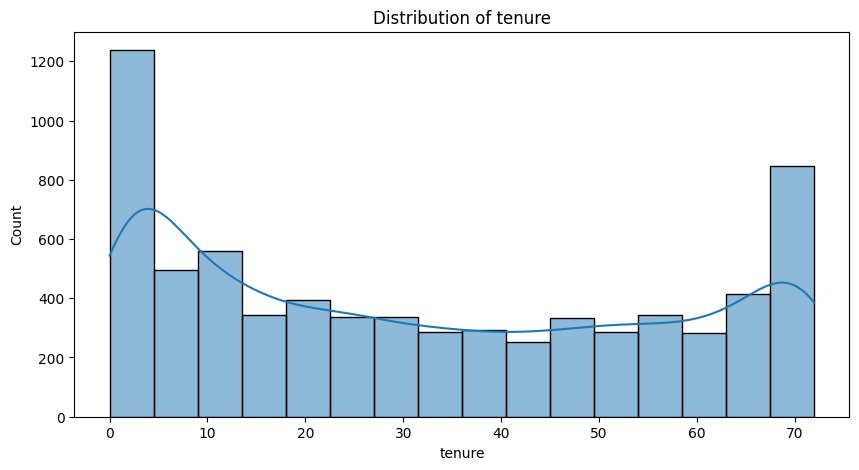

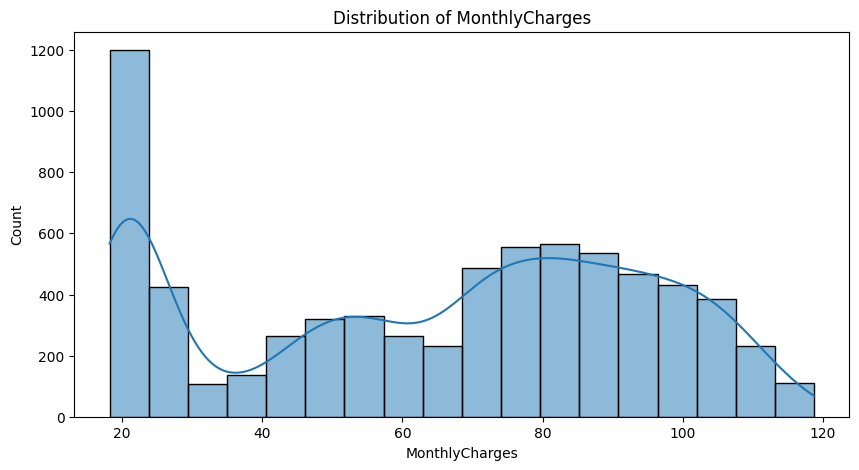

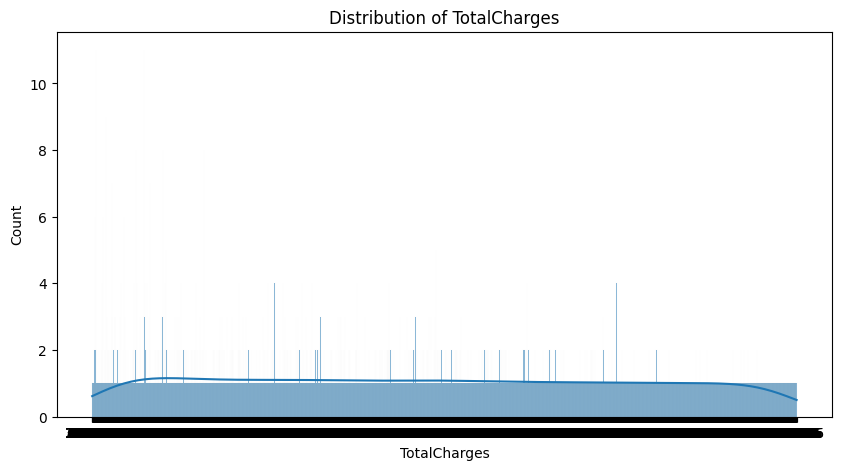

In [ ]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection"
]

for num in numerical_features:
    plt.figure(figsize=(10,5))
    sns.histplot(data=df, x=num, kde=True)
    plt.title(f"Distribution of {num}")
    plt.show()

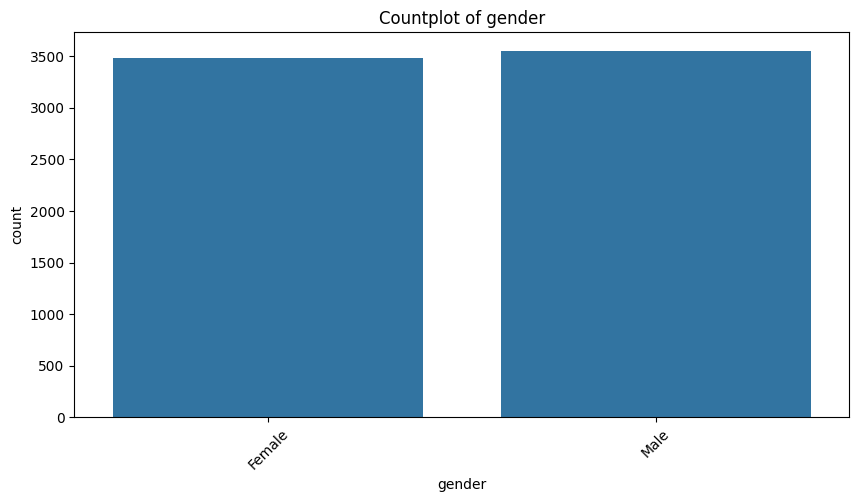

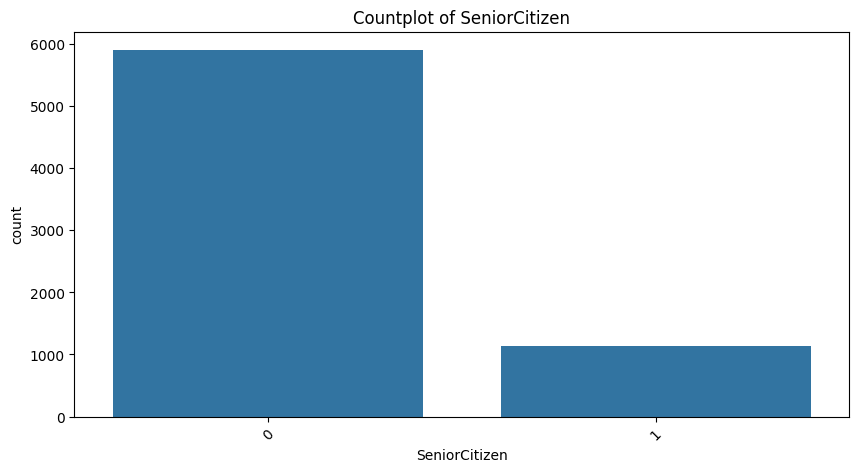

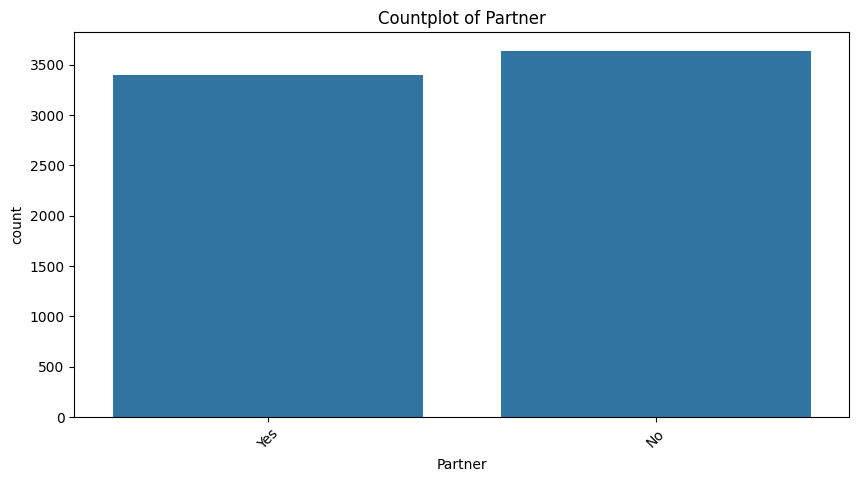

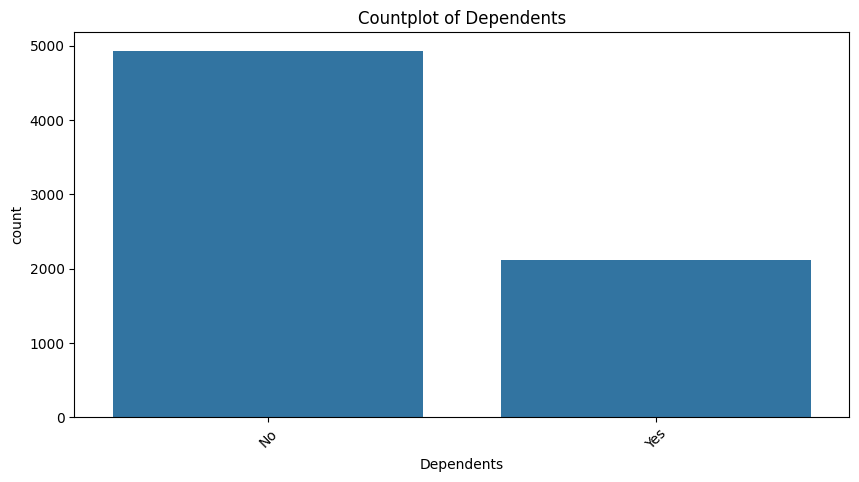

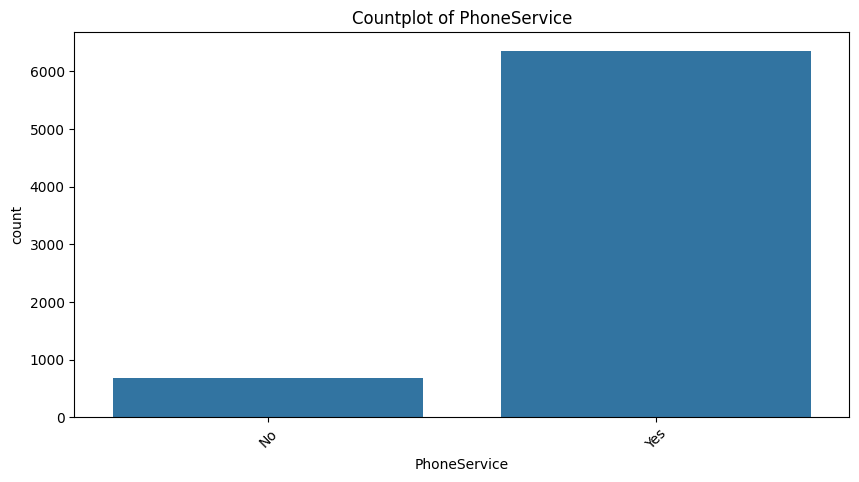

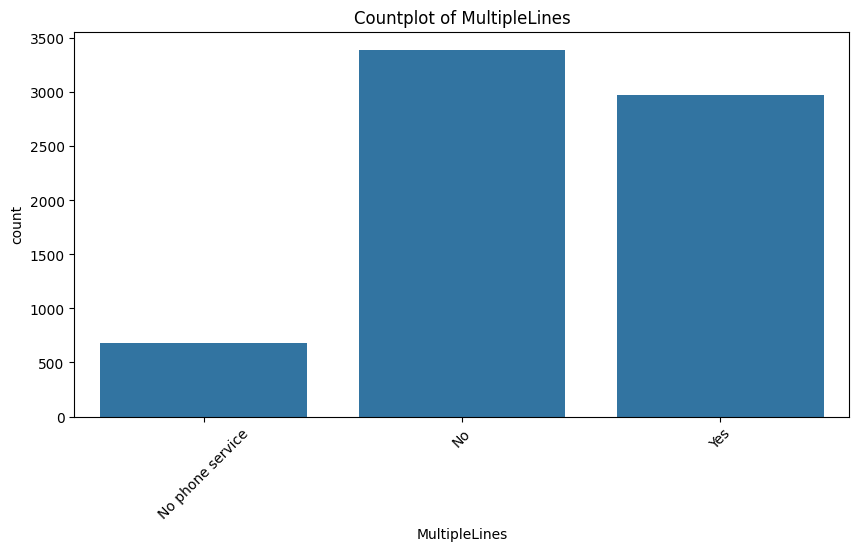

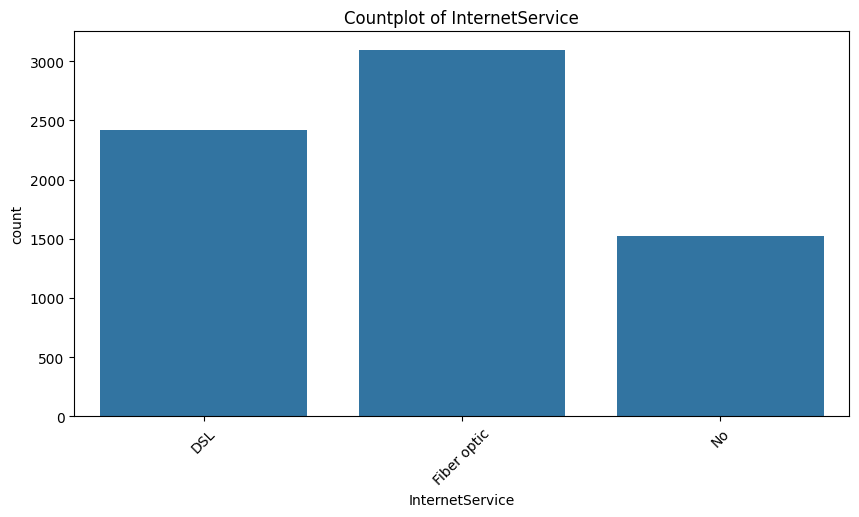

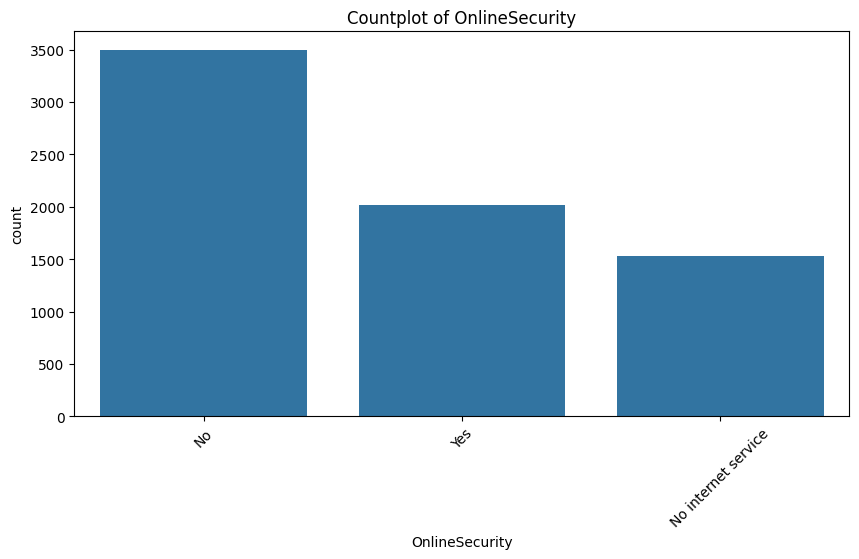

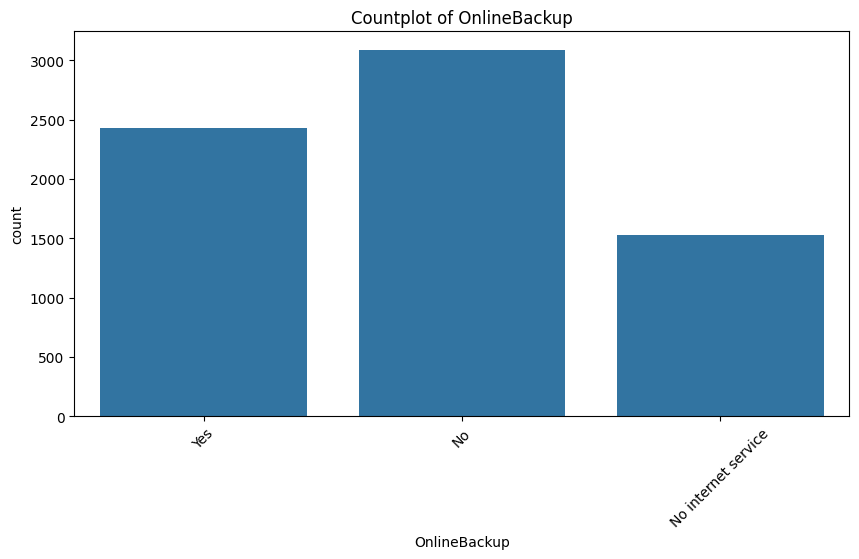

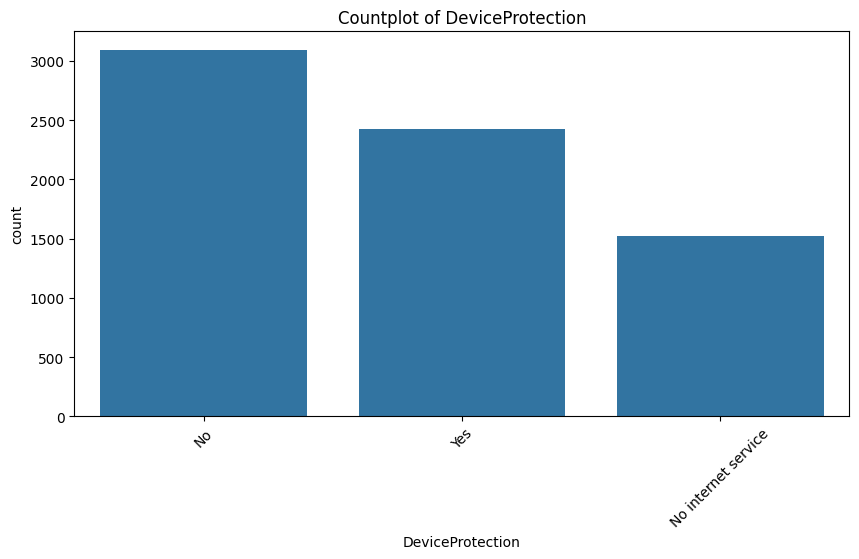

In [ ]:
for col in categorical_features:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

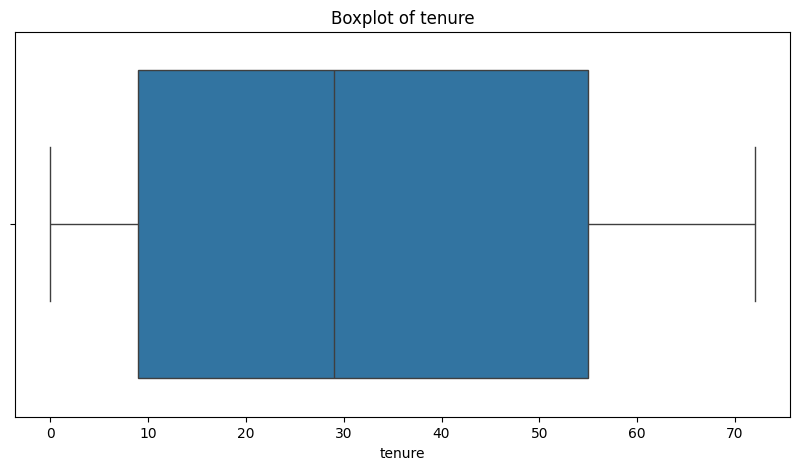

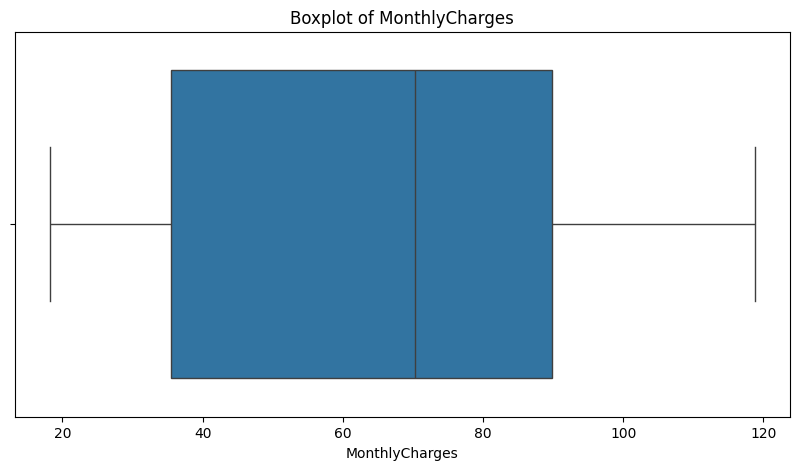

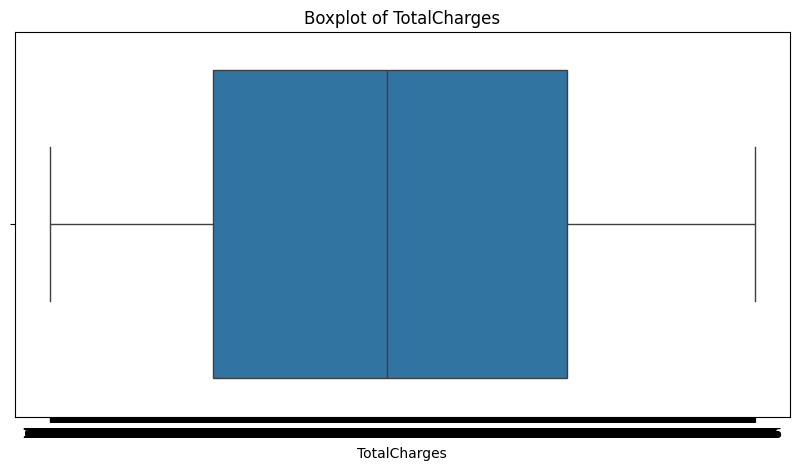

In [ ]:
for num in numerical_features:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df, x=num)
    plt.title(f"Boxplot of {num}")
    plt.show()

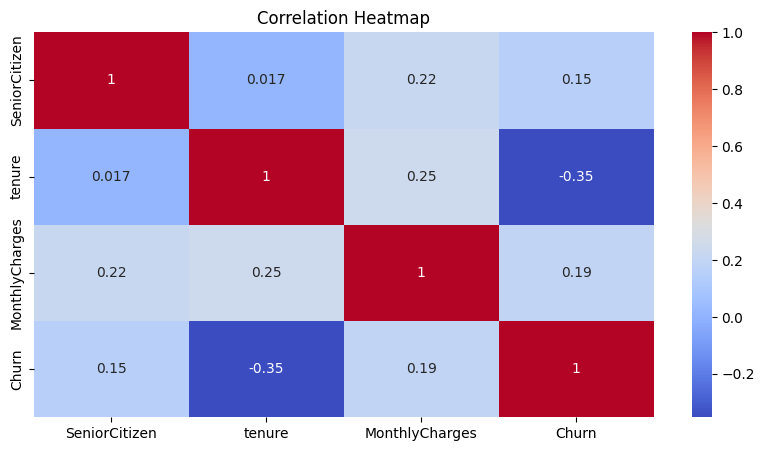

In [ ]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
numeric_df = df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(10,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# step:6 Model Buliding

In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64","float64"]).columns
num_pipeline = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler()),]
)
cat_pipeline = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="most_frequent")),
           ("encoder",OneHotEncoder(drop="first",handle_unknown="ignore"))]
)
preprocessor = ColumnTransformer(
    transformers=[("num",num_pipeline,numerical_cols),("cat",cat_pipeline,categorical_cols)]
)
lr_pipeline = Pipeline(
    steps=[("preprocess",preprocessor),("clf",LogisticRegression())]
)
dt_pipeline = Pipeline(
    steps=[("preprocess",preprocessor),("clf",DecisionTreeClassifier())]
)
rf_pipeline = Pipeline(
    steps=[("preprocess",preprocessor),("clf",RandomForestClassifier(random_state=42))]
)
svc_pipeline = Pipeline(
    steps=[("preprocess",preprocessor),("clf",LinearSVC())]
)
knn_pipeline = Pipeline(
    steps=[("preprocess",preprocessor),("clf",KNeighborsClassifier())]
)
grid_params = {
    "LogisticRegression": {
        "algo": lr_pipeline,
        "params": {
            "clf__C": [0.01,0.1,1,10]
        }
    },
    "DecisionTreeClassifier": {
        "algo": dt_pipeline,
        "params": {
            "clf__max_depth": [3,5,10],
            "clf__min_samples_split": [2,5,10]
        }
    },
    "Random_Forest": {
        "algo": rf_pipeline,
        "params": {
            "clf__n_estimators": [50,100],
            "clf__max_depth": [5,10],
            "clf__min_samples_split": [2,5]
        }
    },
    "Linear_SVC": {
        "algo": svc_pipeline,
        "params": {
            "clf__C": [0.1,1]
        }
    },
    "KNN":{
        "algo": knn_pipeline,
        "params": {
            "clf__n_neighbors": [3, 5, 7]
        }
    }
}
results = []
for name, model in grid_params.items():
  print(f"Running Model: {name}")
  clf = GridSearchCV(
      estimator=model["algo"],
      param_grid=model["params"],
      cv=5,
      scoring="accuracy",
      verbose=1,
      n_jobs=-1
  )
  clf.fit(X_train,y_train)
  best_model = clf.best_estimator_
  y_pred = best_model.predict(X_test)
  report = classification_report(y_test,y_pred)
  print(f"\n{name} classification report\n")
  print(report)
  print("=" * 60)
  results.append({
      "model_name": name,
      "best_params":clf.best_params_,
      "best_score": best_model,
      "classification_report": report
  })
  results_df = pd.DataFrame(results)
  print(results_df)

Running Model: LogisticRegression
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



LogisticRegression classification report

              precision    recall  f1-score   support

          No       0.86      0.91      0.88      1036
         Yes       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.81      1409

           model_name      best_params  \
0  LogisticRegression  {'clf__C': 0.1}   

                                          best_score  \
0  (ColumnTransformer(transformers=[('num',\n    ...   

                               classification_report  
0                precision    recall  f1-score   ...  
Running Model: DecisionTreeClassifier
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



DecisionTreeClassifier classification report

              precision    recall  f1-score   support

          No       0.83      0.93      0.88      1036
         Yes       0.71      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409

               model_name                                        best_params  \
0      LogisticRegression                                    {'clf__C': 0.1}   
1  DecisionTreeClassifier  {'clf__max_depth': 5, 'clf__min_samples_split'...   

                                          best_score  \
0  (ColumnTransformer(transformers=[('num',\n    ...   
1  (ColumnTransformer(transformers=[('num',\n    ...   

                               classification_report  
0                precision    recall  f1-score   ...  
1                precision    recall  f1-score   ...  
Running Model: Random_Forest
Fitting 5 folds for ea

...


Random_Forest classification report

              precision    recall  f1-score   support

          No       0.74      1.00      0.85      1036
         Yes       0.00      0.00      0.00       373

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409

               model_name                                        best_params  \
0      LogisticRegression                                    {'clf__C': 0.1}   
1  DecisionTreeClassifier  {'clf__max_depth': 5, 'clf__min_samples_split'...   
2           Random_Forest  {'clf__max_depth': 5, 'clf__min_samples_split'...   

                                          best_score  \
0  (ColumnTransformer(transformers=[('num',\n    ...   
1  (ColumnTransformer(transformers=[('num',\n    ...   
2  (ColumnTransformer(transformers=[('num',\n    ...   

                               classification_report  
0                precision    reca

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Linear_SVC classification report

              precision    recall  f1-score   support

          No       0.86      0.91      0.88      1036
         Yes       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

               model_name                                        best_params  \
0      LogisticRegression                                    {'clf__C': 0.1}   
1  DecisionTreeClassifier  {'clf__max_depth': 5, 'clf__min_samples_split'...   
2           Random_Forest  {'clf__max_depth': 5, 'clf__min_samples_split'...   
3              Linear_SVC                                    {'clf__C': 0.1}   

                                          best_score  \
0  (ColumnTransformer(transformers=[('num',\n    ...   
1  (ColumnTransformer(transformers=[('num',\n    ...   
2  (ColumnTransformer(transformers=[('num',\n    ...   
3  (ColumnTra

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



KNN classification report

              precision    recall  f1-score   support

          No       0.84      0.87      0.85      1036
         Yes       0.59      0.53      0.56       373

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409

               model_name                                        best_params  \
0      LogisticRegression                                    {'clf__C': 0.1}   
1  DecisionTreeClassifier  {'clf__max_depth': 5, 'clf__min_samples_split'...   
2           Random_Forest  {'clf__max_depth': 5, 'clf__min_samples_split'...   
3              Linear_SVC                                    {'clf__C': 0.1}   
4                     KNN                            {'clf__n_neighbors': 7}   

                                          best_score  \
0  (ColumnTransformer(transformers=[('num',\n    ...   
1  (ColumnTransformer(transformers=[('num',\n    ...

In [ ]:
pd.DataFrame(results)

,model_name,best_params,best_score,classification_report
0,LogisticRegression,{'clf__C': 0.1},"(ColumnTransformer(transformers=[('num',\n ...",precision recall f1-score ...
1,DecisionTreeClassifier,"{'clf__max_depth': 5, 'clf__min_samples_split'...","(ColumnTransformer(transformers=[('num',\n ...",precision recall f1-score ...
2,Random_Forest,"{'clf__max_depth': 5, 'clf__min_samples_split'...","(ColumnTransformer(transformers=[('num',\n ...",precision recall f1-score ...
3,Linear_SVC,{'clf__C': 0.1},"(ColumnTransformer(transformers=[('num',\n ...",precision recall f1-score ...
4,KNN,{'clf__n_neighbors': 7},"(ColumnTransformer(transformers=[('num',\n ...",precision recall f1-score ...


In [ ]:
for result in results:
  if result["model_name"]=="LogisticRegression":
    selected_model = result["best_score"]

In [ ]:
selected_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('clf', LogisticRegression(C=0.1))])